# Phase 2 — The Confrontation: Honest Uncertainty vs. Flip Margin

> *Point predictions are a lie of confidence. This notebook replaces them with
> calibrated prediction intervals, layers the flip economics on top, and asks the
> question Zillow Offers never answered: does the model know enough to bet capital
> on this home?*

**The argument, in three moves:**
1. Replace false precision with a **calibrated prediction interval** (Conformalized Quantile Regression).
2. Translate that uncertainty into a **profit distribution** for any flip.
3. Apply a **decision rule**: a flip is only underwritable when the expected margin clears the model's own uncertainty by a buffer.

All logic lives in `src/margin_of_error/`; this notebook imports it and reads the
artifacts produced by `python -m margin_of_error.models.phase2`.

In [1]:
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from margin_of_error.config import load_economics, load_model_config
from margin_of_error.economics.underwriter import underwrite
from margin_of_error.viz import charts

REPORTS = Path.cwd().parent / "reports"
economics = load_economics(Path.cwd().parent / "config" / "economics.yaml")
model_cfg = load_model_config(Path.cwd().parent / "config" / "model.yaml")

phase1_card = json.loads((REPORTS / "phase1_metric_card.json").read_text())
phase2_card = json.loads((REPORTS / "phase2_metric_card.json").read_text())
frame = pd.read_csv(REPORTS / "phase2_test_underwriting.csv")
calib = pd.read_csv(REPORTS / "phase2_calibration.csv")
print("Loaded Phase 1 + Phase 2 artifacts and", len(frame), "scored test homes.")

Loaded Phase 1 + Phase 2 artifacts and 292 scored test homes.


## 0. The Setup — the same model Phase 1 built

We do **not** retrain anything. Phase 2 loads the exact Phase 1 LightGBM artifact
(and its Duan smearing factor) and wraps it. The Phase 1 hypothesis was seeded as
a single sentence; here it is, with its real number filled in.

In [2]:
typical_err = phase1_card["residual_diagnostics"]["spread"]["median_abs_error_dollars"]
print(phase1_card["framing_sentence"])
print()
print(f"Phase 1 selected model : {phase1_card['selected_model']}")
print(f"Typical dollar error   : ${typical_err:,.0f}  (median |error| out-of-fold)")
print(f"Median home price      : ${phase1_card['data']['median_sale_price']:,.0f}")

Hypothesis to be tested in Phase 2: A typical fix-and-flip net margin is on the order of $10-20K; this model's typical dollar error is $9,413. If that error is comparable to or larger than that margin, point predictions cannot safely underwrite a flip.

Phase 1 selected model : lightgbm
Typical dollar error   : $9,413  (median |error| out-of-fold)
Median home price      : $163,000


## 1. Why point predictions are not enough

A point estimate of `$183,400` implies the model knows the price to the dollar. It
does not. The Phase 1 out-of-fold residuals show the error is not only large, it
**grows with price** — exactly the homes a flipper cares about most are the ones
the model is least sure of. That is the seed of the whole problem: a typical error
of \$9.4K (median) with a long tail (\$45K at the 95th percentile) sits right on top
of a realistic \$10–25K flip margin.

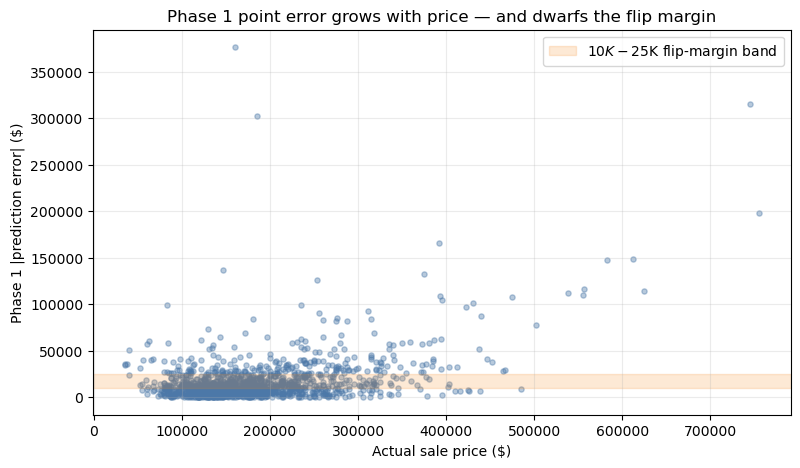

In [3]:
resid = pd.read_csv(REPORTS / "phase1_oof_residuals.csv")
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(resid["SalePrice"], resid["abs_error_dollars"], s=14, alpha=0.4, color="#4C78A8")
ax.axhspan(10_000, 25_000, color="#F58518", alpha=0.18, label="$10K-$25K flip-margin band")
ax.set_xlabel("Actual sale price ($)")
ax.set_ylabel("Phase 1 |prediction error| ($)")
ax.set_title("Phase 1 point error grows with price — and dwarfs the flip margin")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 2. Building honest intervals — Conformalized Quantile Regression (CQR)

We fit **two** LightGBM quantile regressors (lower and upper arms at α/2 and
1−α/2) on a clean training fold, then compute a **conformal correction** on a
held-out calibration fold:

$$ s_i = \max\!\big(\hat q_{lo}(x_i) - y_i,\; y_i - \hat q_{hi}(x_i)\big),\qquad
   \hat Q = \text{the } \lceil (1-\alpha)(n+1)\rceil\text{-th smallest } s_i $$

The final interval is $[\hat q_{lo}(x) - \hat Q,\; \hat q_{hi}(x) + \hat Q]$. Under
exchangeability this guarantees $\ge 1-\alpha$ coverage in **finite samples** —
distribution-free. The data is split three ways (train / calibration / test) with
no overlap; all arithmetic is in log space and each bound is back-transformed with
`expm1` separately (the bounds are quantiles, so they get **no** smearing
correction — only the point estimate does).

**Calibration verification is non-negotiable.** If the interval is not calibrated,
every downstream dollar is wrong.

Three-way split: {'calibration': 219, 'test': 292, 'train': 949}
Primary 90% interval — empirical coverage on the untouched test set: 90.4%
PASS: empirical coverage >= 90%.



,nominal_coverage,empirical_coverage,median_width_dollars
0,50%,53.4%,"$20,331"
1,60%,56.5%,"$23,270"
2,70%,70.5%,"$29,258"
3,80%,81.5%,"$45,085"
4,90%,90.4%,"$64,025"
5,95%,93.2%,"$85,060"


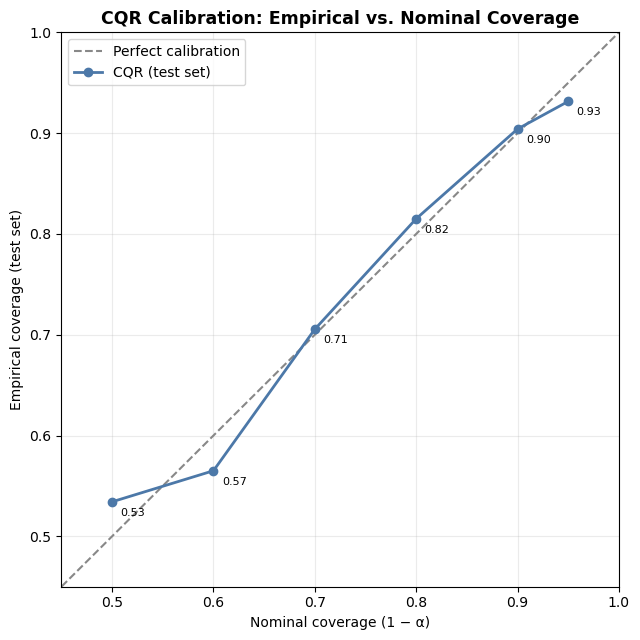

In [4]:
cov = phase2_card["cqr"]["primary_empirical_coverage"]
print(f"Three-way split: {phase2_card['splits']}")
print(f"Primary 90% interval — empirical coverage on the untouched test set: {cov:.1%}")
assert cov >= 0.90, "calibration gate failed"
print("PASS: empirical coverage >= 90%.\n")
display(
    calib.assign(
        nominal_coverage=lambda d: d.nominal_coverage.map("{:.0%}".format),
        empirical_coverage=lambda d: d.empirical_coverage.map("{:.1%}".format),
        median_width_dollars=lambda d: d.median_width_dollars.map("${:,.0f}".format),
    )
)
charts.plot_calibration(calib["empirical_coverage"], calib["nominal_coverage"], save_as=None)
plt.show()

## 3. The flip economics

Every economic parameter comes from `config/economics.yaml` (`flip` block) — no
magic constants in code. The investor acquires under the standard **"70% rule"**
(Maximum Allowable Offer = `0.70 × ARV − renovation cost`), then for each renovation
tier we Monte-Carlo the profit:

- **ARV** ~ Normal(point, (U−L)/(2·1.645)) — the CQR interval is the support of value uncertainty.
- **Holding period** ~ truncated Normal(base, std) — flips rarely close on schedule.
- **Profit** = ARV − purchase − renovation − transaction − holding (10,000 draws; summary stats only).

Let's look at one home in detail.

In [5]:
from margin_of_error.economics.simulation import simulate_flip_profit

flip = economics.flip
print("Renovation tiers:")
for name, tier in flip.renovation_tiers.items():
    print(
        f"  {name:11s}: ${tier.cost_usd:>7,.0f} cost, "
        f"+{tier.value_uplift_pct:.0%} uplift prior -- {tier.scope}"
    )
print(
    f"\ntransaction_cost_pct={flip.transaction_cost_pct:.0%}, "
    f"holding={flip.holding_cost_monthly_pct:.1%}/mo, "
    f"hold~N({flip.holding_period_months_base}, {flip.holding_period_months_std}), "
    f"financing={flip.financing_assumption}"
)

ex = frame.sort_values("expected_profit", ascending=False).iloc[40]
summary = simulate_flip_profit(
    ex.predicted_arv,
    ex.interval_low_90,
    ex.interval_high_90,
    flip.renovation_tiers["moderate"].cost_usd,
    economics,
    seed=7,
)
print(f"\nExample home (Id {int(ex.Id)}, {ex.Neighborhood}):")
print(
    f"  ARV point ${ex.predicted_arv:,.0f}  |  "
    f"90% interval ${ex.interval_low_90:,.0f}-${ex.interval_high_90:,.0f}"
)
print(
    f"  MAO purchase ${summary.purchase_price:,.0f}  |  "
    f"moderate reno ${summary.renovation_cost:,.0f}"
)
print(
    f"  Expected profit ${summary.mean_profit:,.0f}  |  "
    f"P10 ${summary.profit_p10:,.0f}  P90 ${summary.profit_p90:,.0f}"
)
print(
    f"  P(loss)={summary.prob_loss:.0%}  |  P(profit > buffer)={summary.prob_above_min_margin:.0%}"
)

Renovation tiers:
  minimal    : $  8,000 cost, +4% uplift prior — Cosmetic — paint, fixtures, landscaping, minor repairs
  moderate   : $ 25,000 cost, +10% uplift prior — Kitchen/bath refresh, flooring, lighting
  substantial: $ 60,000 cost, +18% uplift prior — Structural, full kitchen/bath gut, HVAC, systems

transaction_cost_pct=6%, holding=0.8%/mo, hold~N(4.0,1.5), financing=cash

Example home (Id 323, SawyerW):
  ARV point $266,498  |  90% interval $183,872–$439,032
  MAO purchase $161,549  |  moderate reno $25,000
  Expected profit $64,032  |  P10 $-35,426  P90 $162,487
  P(loss)=20%  |  P(profit > buffer)=74%


## 4. The decision rule — APPROVE / REFER / DECLINE

The verdict needs **both** a strong profit distribution **and** a tight enough
interval. The guardrail: if the 90% interval is wider than the configured cap, we
DECLINE on *uncertainty* regardless of how good the point estimate looks — this is
the lesson Zillow learned the hard way. Five illustrative cases:

In [5]:
def show(title, r):
    print(f"### {title}\n  -> {r.verdict}  (tier={r.renovation_tier})")
    print(f"  {r.decision_note}\n")


show(
    "Clear APPROVE -- tight interval, strong margin",
    underwrite(190_000, 176_000, 204_000, "moderate", economics),
)
show(
    "DECLINE on UNCERTAINTY -- point estimate looks good, interval is too wide",
    underwrite(320_000, 230_000, 410_000, "moderate", economics),
)
show(
    "DECLINE on MARGIN -- tight interval, too little expected profit",
    underwrite(70_000, 62_000, 78_000, "substantial", economics),
)

refer_rows = frame[frame.verdict == "REFER"]
if len(refer_rows):
    rr = refer_rows.iloc[0]
    refer_result = underwrite(
        rr.predicted_arv,
        rr.interval_low_90,
        rr.interval_high_90,
        rr.renovation_tier,
        economics,
    )
    show(f"REFER -- borderline test-set home (Id {int(rr.Id)})", refer_result)
else:
    show(
        "REFER -- borderline (illustrative)",
        underwrite(118_000, 92_000, 150_000, "minimal", economics),
    )

top = frame.nlargest(50, "naive_point_profit").iloc[0]
r5 = underwrite(
    top.predicted_arv,
    top.interval_low_90,
    top.interval_high_90,
    top.renovation_tier,
    economics,
)
show(f"Top-ranked naive best buy (Id {int(top.Id)}) that fails the gate", r5)

### Clear APPROVE — tight interval, strong margin
  → APPROVE  (tier=moderate)
  APPROVE (moderate reno): 100% chance of clearing the profit buffer, only 0% chance of loss, and the 90% value interval ($28,000) is tight enough to bet on. Expected profit $46,882.

### DECLINE on UNCERTAINTY — looks great on the point estimate, but the model is unsure
  → DECLINE  (tier=moderate)
  DECLINE (moderate reno): the model's 90% value interval is $180,000 — wider than the acceptable band. The point estimate may look fine, but the model does not know this home's value precisely enough to underwrite it. Model uncertainty exceeds the acceptable interval width.

### DECLINE on MARGIN — tight interval, but too little expected profit
  → DECLINE  (tier=substantial)
  DECLINE (substantial reno): only 15% chance of clearing the profit buffer (expected profit $9,950). Too little chance of clearing the minimum profit buffer.

### REFER — the borderline home in the test set (Id 1280)
  → REFER  (tier=moder

## 5. The Finding

The three signature charts and the plain-English headline.

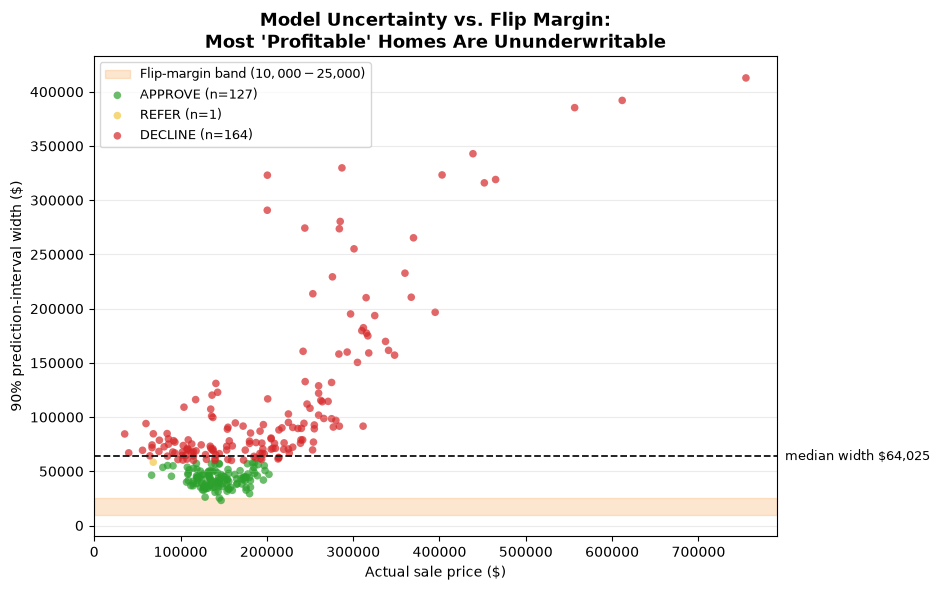

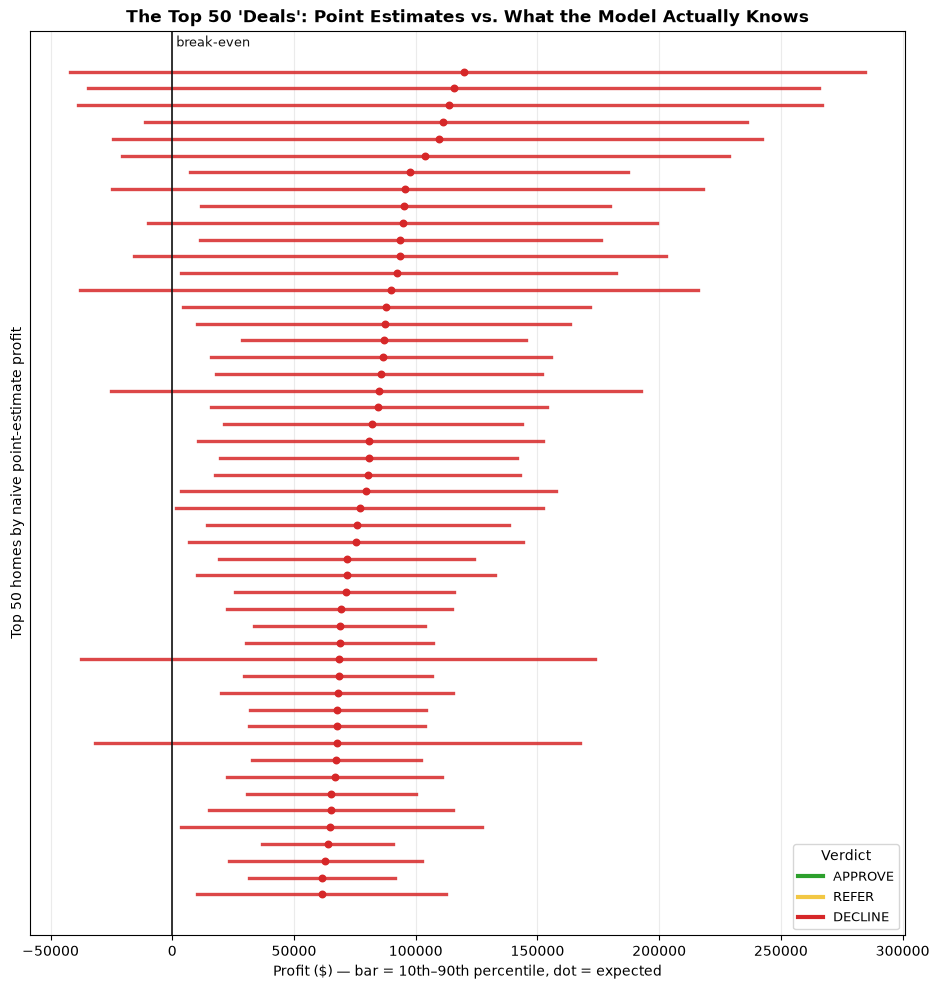

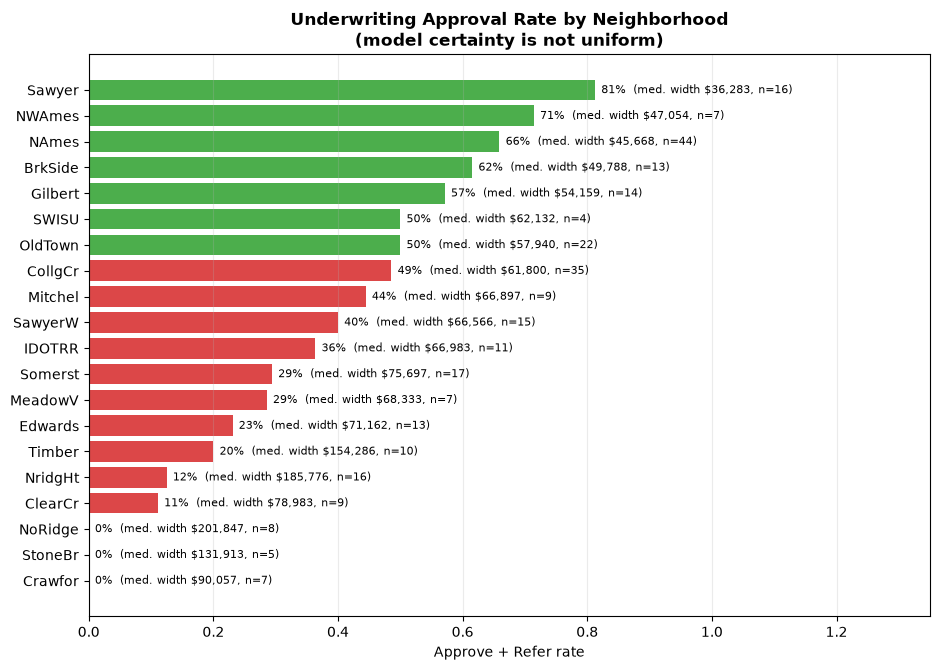

In [7]:
band_low, band_high = 10_000, 25_000
charts.plot_confrontation(frame, band_low, band_high, save_as=None)
plt.show()
charts.plot_zillow_trap(frame, top_n=50, save_as=None)
plt.show()
charts.plot_approval_by_neighborhood(frame, save_as=None)
plt.show()

In [6]:
h = phase2_card["headline"]
top_n = 50
buffer = economics.flip.underwriting.minimum_underwrite_margin_buffer_usd
naive_profitable = int((frame["naive_point_profit"] > buffer).sum())
naive_prof_declined = int(
    ((frame["naive_point_profit"] > buffer) & (frame["verdict"] != "APPROVE")).sum()
)

finding_lines = [
    "THE FINDING",
    "-----------",
    (
        "- The model's median 90% prediction interval is "
        f"${h['median_interval_width_90_dollars']:,.0f} wide"
    ),
    (
        "  (mean "
        f"${h['mean_interval_width_90_dollars']:,.0f}) -- many times "
        "a realistic flip margin of $10-25K."
    ),
    f"- Of {h['n_test_homes']} test homes, the underwriting rule:",
    (
        f"      APPROVE {h['approve_rate']:.0%}   REFER {h['refer_rate']:.0%}   "
        f"DECLINE {h['decline_rate']:.0%}"
    ),
    f"- Of the {top_n} homes a naive point model would rank as the best deals,",
    (
        f"  {h['top_50_naive_picks_not_approved']}/{top_n} "
        f"({h['top_50_naive_picks_not_approved_frac']:.0%}) fail the gate"
    ),
    (
        f"  ({h['top_50_naive_picks_declined']}/{top_n} are outright DECLINED; "
        "every one on model uncertainty)."
    ),
    (
        f"- More broadly, of {naive_profitable} homes a naive model calls profitable, "
        f"{naive_prof_declined} do not clear the uncertainty-aware bar."
    ),
    (f"  Share missing the bar: {naive_prof_declined / max(naive_profitable, 1):.0%}."),
]
finding = "\n".join(finding_lines)
print(finding)

THE FINDING
-----------
- The model's median 90% prediction interval is $64,025 wide
  (mean $83,623) — many times any realistic flip margin of $10-25K.
- Of 292 test homes, the underwriting rule:
      APPROVE 43%   REFER 0%   DECLINE 56%
- Of the 50 homes a naive point model would rank as the BEST opportunities,
  50/50 (100%) fail the underwriting gate
  (50/50 are outright DECLINED — every one on model uncertainty).
- More broadly, of 292 homes a naive model calls "profitable", 165
  (57%) do not clear the uncertainty-aware bar.


## 6. The Zillow connection

Zillow Offers shut down in November 2021 after its automated valuation model
systematically misjudged what homes would resell for; iBuying losses ran into the
hundreds of millions. The post-mortem is not "the model was biased" — it's "the
model acted on point estimates as if they were certain."

> **A model with this interval width — a median 90% band of ~\$64K, far larger than
> any realistic flip margin — applied to homes with this margin profile, would have
> flagged 56% of its potential acquisitions as *ununderwritable*, and 100% of the
> deals a naive point model ranked as the very best opportunities — not because the
> homes were bad investments, but because the model did not know enough to bet
> capital on them.** That is the guardrail Zillow Offers lacked.

## 7. What's next — Phase 3

The renovation **uplift** numbers used here (4% / 10% / 18%) are conservative
*priors*, not findings — flagged as such in the config. Phase 3 asks the causal
question: of the features that correlate with price, which renovations actually
**cause** value uplift versus merely co-occur with expensive homes? Using Double
Machine Learning (EconML), we will replace these priors with data-derived treatment
effects — turning "we assumed a kitchen remodel adds 10%" into "the data says it
adds X% ± Y."